In [77]:
import numpy as np
import pandas as pd
import pickle
import glob
import cv2
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.layers import Conv2D
from keras.models import Sequential, Model
from keras.applications.vgg19 import VGG19
from keras.applications.vgg16 import VGG16
from sklearn.ensemble import RandomForestClassifier

In [26]:
train_images = []
train_labels = []

for dir_path in glob.glob(r'D:\ML\computer vision projects\sandstone microstructure (Semantic Segmintation)\Data\Train\images'):
    print(dir_path)
    for img_path in glob.glob(os.path.join(dir_path, "*.png")):
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (256,256))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        train_images.append(img)

D:\ML\computer vision projects\sandstone microstructure (Semantic Segmintation)\Data\Train\images


In [27]:
for dir_path in glob.glob(r'D:\ML\computer vision projects\sandstone microstructure (Semantic Segmintation)\Data\Train\masks'):
    print(dir_path)
    for img_path in glob.glob(os.path.join(dir_path, "*.png")):
        mask = cv2.imread(img_path, 0)
        mask = cv2.resize(img, (256,256))
        train_labels.append(img)

D:\ML\computer vision projects\sandstone microstructure (Semantic Segmintation)\Data\Train\masks


In [28]:
train_images = np.array(train_images)
train_labels = np.array(train_labels)

In [33]:
X_train = train_images
y_train = train_labels

In [34]:
X_train.shape, y_train.shape

((30, 256, 256, 3), (30, 256, 256, 3))

In [39]:
model = VGG19(include_top=False,input_shape=(256,256,3))

In [40]:
model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
for layer in model.layers:
    layer.trainable = False

In [42]:
model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [43]:
new_model = Model(inputs= model.input, outputs= model.get_layer("block1_conv2").output)

In [45]:
new_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,720 (151.25 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 38,720 (151.25 KB)

In [46]:
features = new_model.predict(X_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


In [52]:
features[0][0][0].shape

(64,)

In [55]:
features[0][0].shape

(256, 64)

In [56]:
features[0].shape

(256, 256, 64)

In [57]:
features.shape

(30, 256, 256, 64)

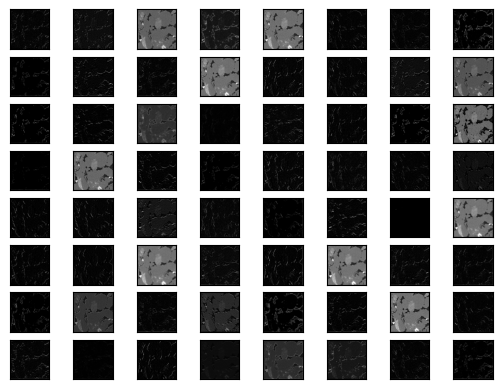

In [58]:
square = 8
i = 1
for _ in range(square):
    for _ in range(square):
        ax = plt.subplot(square,square,i)
        ax.set_yticks([])
        ax.set_xticks([])
        plt.imshow(features[0,:,:,i-1], cmap='gray')
        i += 1

plt.show()

In [59]:
X = features
X = X.reshape(-1 , X.shape[3])

In [60]:
Y = y_train.reshape(-1)

In [61]:
X.shape, Y.shape

((1966080, 64), (5898240,))

In [63]:
Y[:10]

array([255, 255, 255, 255, 255, 255, 255, 255, 255, 255], dtype=uint8)

In [64]:
Y[:-10]

array([255, 255, 255, ...,  83,  95,  95], dtype=uint8)

In [66]:
dataset = pd.DataFrame(X)

# Ensure label length matches dataset rows (one label per pixel feature row)
if Y.shape[0] != len(dataset):
	Y_fixed = y_train[..., 0].reshape(-1)   # use one channel from mask
else:
	Y_fixed = Y

dataset['label'] = Y_fixed

In [68]:
dataset.shape

(1966080, 65)

In [71]:
print(dataset['label'].unique())
print(dataset['label'].value_counts())

[255 227 203 171 141 124 129 134 137 128 127 138 125 117 120 122 113 110
 106 119 121 123 118 114 116 152 241 250 234 205 194 182 163 147 131 157
 186 213 237 195 148 146 151 149 156 155 144 133 139 150 145 140 130 132
  73  44  68  82  87 100 112 108 104 103 115 126 107  93  59  39  61  45
  37  34  35  41  40  36  46  78 135 142 153 154 109  76  79  85  71  65
  84  54  48  91  72  28  21  51  62  90 143 253 229 199 159 105 111 136
 204 244 236 228 187 162 190 224 231 221 215 226 239 223 165 166 158  77
  27  53  60  98  97  56  80  86  75  50  29  43  63 161 102  70  92  49
  52  66  83  81 198 179 178 160 209 249 251 177 192 238 217 200 206 167
  38  18  19  88 101  95  94  67  31  57  74  55  89 201 173 216 254 252
 246 222 175 233 174 172 181 191  15   9  10  17  99  33  30  69  42 211
 188 210 185 168 242 169 183 202  32  23  16   7  96  26  24 220 243 208
 180 230 218 176 164 170  25  64  20 193 245 235  22   5 240 214   0  12
  47 232 207 212 196  13  58 248 247 219   1  11  1

In [72]:
dataset = dataset[dataset['label'] != 0]

In [73]:
dataset.shape

(1962810, 65)

In [74]:
X_Rf = dataset.drop('label' , axis=1)
Y_Rf = dataset['label']

In [78]:
model = RandomForestClassifier(n_estimators=50 , random_state= 42)

In [80]:
# Reduce memory usage before fitting
X_rf_mem = X_Rf.astype(np.float32)
y_rf_mem = Y_Rf.astype(np.uint8)

# Train on a capped random subset to avoid MemoryError
max_samples = 200000
if len(X_rf_mem) > max_samples:
	rng = np.random.RandomState(42)
	idx = rng.choice(len(X_rf_mem), size=max_samples, replace=False)
	X_rf_mem = X_rf_mem.iloc[idx]
	y_rf_mem = y_rf_mem.iloc[idx]

# Use a lighter forest configuration
model = RandomForestClassifier(
	n_estimators=20,
	max_depth=12,
	max_samples=0.5,
	random_state=42,
	n_jobs=-1
)

model.fit(X_rf_mem, y_rf_mem)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [81]:
filename = "RF_MODEL.pickle"
pickle.dump(model, open(filename, 'wb'))

In [82]:
loaded_model = pickle.load(open(filename,'rb'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


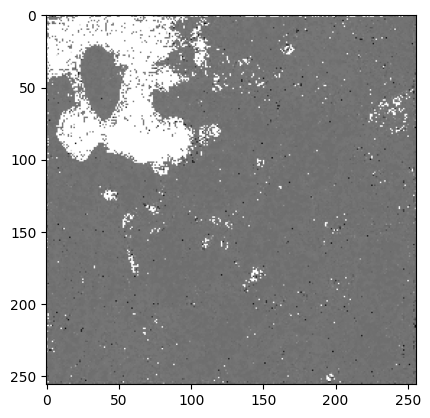

In [85]:
test_img = cv2.imread(r'D:\ML\computer vision projects\sandstone microstructure (Semantic Segmintation)\Data\Test\images\kaggle_test_014.png', cv2.IMREAD_COLOR)       
test_img = cv2.resize(test_img, (256, 256))
test_img = cv2.cvtColor(test_img, cv2.COLOR_RGB2BGR)
test_img = np.expand_dims(test_img, axis=0)

#predict_image = np.expand_dims(X_train[8,:,:,:], axis=0)
X_test_feature = new_model.predict(test_img)
X_test_feature = X_test_feature.reshape(-1, X_test_feature.shape[3])

prediction = loaded_model.predict(X_test_feature)

#View and Save segmented image
prediction_image = prediction.reshape(test_img.shape[1], test_img.shape[2])
plt.imshow(prediction_image, cmap='gray')
plt.imsave('test.jpg', prediction_image, cmap='gray')